# Cell 1 — Imports & Config

## Why XGBoost?

### What it is
XGBoost (Extreme Gradient Boosting) is an ensemble method that builds many small decision trees sequentially,
each one correcting the errors of the previous. The final prediction is the sum of all trees.
We train one independent model per position (QB, RB, WR, TE) rather than a single model for all players,
since the features that matter for a QB (passing attempts, air yards) are largely irrelevant for a RB.

---

### Why it fits this problem well

**Handles mixed feature types naturally**
Our feature set mixes rolling stats, binary flags (is_home, is_turf), availability scores (0–1),
counts (depth_chart_position), and continuous metrics (EPA, Vegas lines) without any scaling or encoding needed.
XGBoost handles all of these natively — unlike linear models or neural nets which require careful normalization.

**Robust to noisy, tabular sports data**
Fantasy football is inherently noisy. XGBoost's regularization parameters (reg_alpha, reg_lambda)
and tree depth constraints (max_depth=4) prevent the model from memorizing flukey individual games
and instead learn stable patterns across thousands of player-weeks.

**No assumption of linearity**
The relationship between features and fantasy output is not linear — a QB on a short week playing
in a dome against a bad secondary is not simply the sum of individual effects. Decision trees capture
these interaction effects (e.g. high implied team total AND good matchup) automatically.

**Fast to train and retrain**
With ~10,000 training rows per position and 80 features, each model trains in seconds.
This matters because the pipeline is designed to be re-run each season as new data arrives.

**Interpretable via feature importance**
Unlike neural networks, XGBoost exposes feature importances that directly explain which signals
the model relies on most. The importance chart in the previous cell makes it easy to audit
whether the model is learning football logic or overfitting to noise.

---

### Weaknesses and limitations

**No memory of sequence or context**
XGBoost treats each row as independent. It doesn't know that a player had 3 great weeks in a row
building momentum, or that a team just fired their offensive coordinator mid-season.
The rolling window features partially compensate for this, but a sequence model (LSTM, Transformer)
would capture temporal dynamics more naturally.

**Can't extrapolate beyond training distribution**
If a player's usage pattern in 2025 looks unlike anything in 2020–2024 (e.g. a historically unique
workload for a rookie), the model may underperform. Tree-based models predict within the range
of values they've seen — they don't generalize beyond training data the way linear models can.

**Per-position models miss cross-positional context**
A team losing its WR1 to injury affects the RB's target share too, but the RB model only sees
a binary `starter_wr_availability` flag — not the magnitude of the WR's lost production.
More sophisticated injury modeling could capture these cascading effects.

**Frozen until retrained**
The model learns patterns from historical seasons and doesn't update week-to-week.
A team that dramatically changes its offensive scheme mid-season won't be reflected until
the model is retrained on data that includes that change.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import KFold

# ── Constants ──────────────────────────────────────────────────────────────────
RANDOM_SEED  = 42
DATA_PATH    = "features_dataset.csv"
MODEL_DIR    = "models"
TRAIN_SEASONS = [2020, 2021, 2022, 2023, 2024]
TEST_SEASON   = 2025
POSITIONS     = ["QB", "RB", "WR", "TE"]

os.makedirs(MODEL_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)

print("Libraries loaded. Model dir:", MODEL_DIR)

Libraries loaded. Model dir: models


In [53]:
# Run from fantasy/ directory -- DATA_PATH and MODEL_DIR are relative
df = pd.read_csv(DATA_PATH)

IDENTITY_COLS = ['player_id', 'player_display_name', 'position', 'team',
                 'opponent_team', 'season', 'week']
TARGET_COL    = 'target_half_ppr'
FEATURE_COLS  = [c for c in df.columns if c not in IDENTITY_COLS + [TARGET_COL]]

# QBs have 0 values for all receiving-role stats -- including them adds noise to the QB model
QB_EXCL = [c for c in FEATURE_COLS if any(k in c for k in [
    'targets', 'receptions', 'receiving',
    'target_share', 'air_yards_share', 'wopr',
])]

FEATURE_COLS_BY_POS = {
    'QB': [c for c in FEATURE_COLS if c not in QB_EXCL],
    'RB': FEATURE_COLS,
    'WR': FEATURE_COLS,
    'TE': FEATURE_COLS,
}

print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Base feature pool: {len(FEATURE_COLS)}  |  QB excluded (receiving-role): {len(QB_EXCL)}')
print(f'Train seasons: {TRAIN_SEASONS}  |  Test season: {TEST_SEASON}')
print()
print('Features per position:')
for pos, cols in FEATURE_COLS_BY_POS.items():
    print(f'  {pos}: {len(cols)} features')
print()
print('Rows per position x season:')
print(df.groupby('position')['season'].value_counts().unstack().to_string())


Dataset: 30,213 rows x 88 cols
Base feature pool: 80  |  QB excluded (receiving-role): 22
Train seasons: [2020, 2021, 2022, 2023, 2024]  |  Test season: 2025

Features per position:
  QB: 58 features
  RB: 80 features
  WR: 80 features
  TE: 80 features

Rows per position x season:
season    2020  2021  2022  2023  2024  2025
position                                    
QB         474   560   542   570   577   571
RB        1162  1313  1396  1314  1351  1397
TE         899  1046  1073  1057  1087  1145
WR        1856  2175  2097  2192  2144  2215


In [54]:
XGB_PARAMS = dict(
    n_estimators     = 500,
    max_depth        = 4,
    learning_rate    = 0.05,
    min_child_weight = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.5,
    reg_lambda       = 1.0,
    objective        = 'reg:squarederror',
    random_state     = RANDOM_SEED,
    tree_method      = 'hist',
    n_jobs           = -1,
)

results = {}

for pos in POSITIONS:
    pos_feats = FEATURE_COLS_BY_POS[pos]
    pos_df = df[df['position'] == pos].copy()
    train  = pos_df[pos_df['season'].isin(TRAIN_SEASONS)]
    test   = pos_df[pos_df['season'] == TEST_SEASON]

    X_train, y_train = train[pos_feats], train[TARGET_COL]
    X_test,  y_test  = test[pos_feats],  test[TARGET_COL]

    model = XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = root_mean_squared_error(y_test, preds)

    save_path = os.path.join(MODEL_DIR, f'{pos.lower()}_model.pkl')
    joblib.dump({'model': model, 'feature_cols': pos_feats}, save_path)

    results[pos] = {'mae': mae, 'rmse': rmse,
                    'train_rows': len(X_train), 'test_rows': len(X_test)}
    print(f'{pos:<4}  features={len(pos_feats):>2}  train={len(X_train):>5}  test={len(X_test):>4}  '
          f'MAE={mae:.2f}  RMSE={rmse:.2f}  -> {save_path}')


QB    features=58  train= 2723  test= 571  MAE=7.07  RMSE=8.71  -> models\qb_model.pkl
RB    features=80  train= 6536  test=1397  MAE=4.49  RMSE=6.57  -> models\rb_model.pkl
WR    features=80  train=10464  test=2215  MAE=3.92  RMSE=5.39  -> models\wr_model.pkl
TE    features=80  train= 5162  test=1145  MAE=3.26  RMSE=4.74  -> models\te_model.pkl


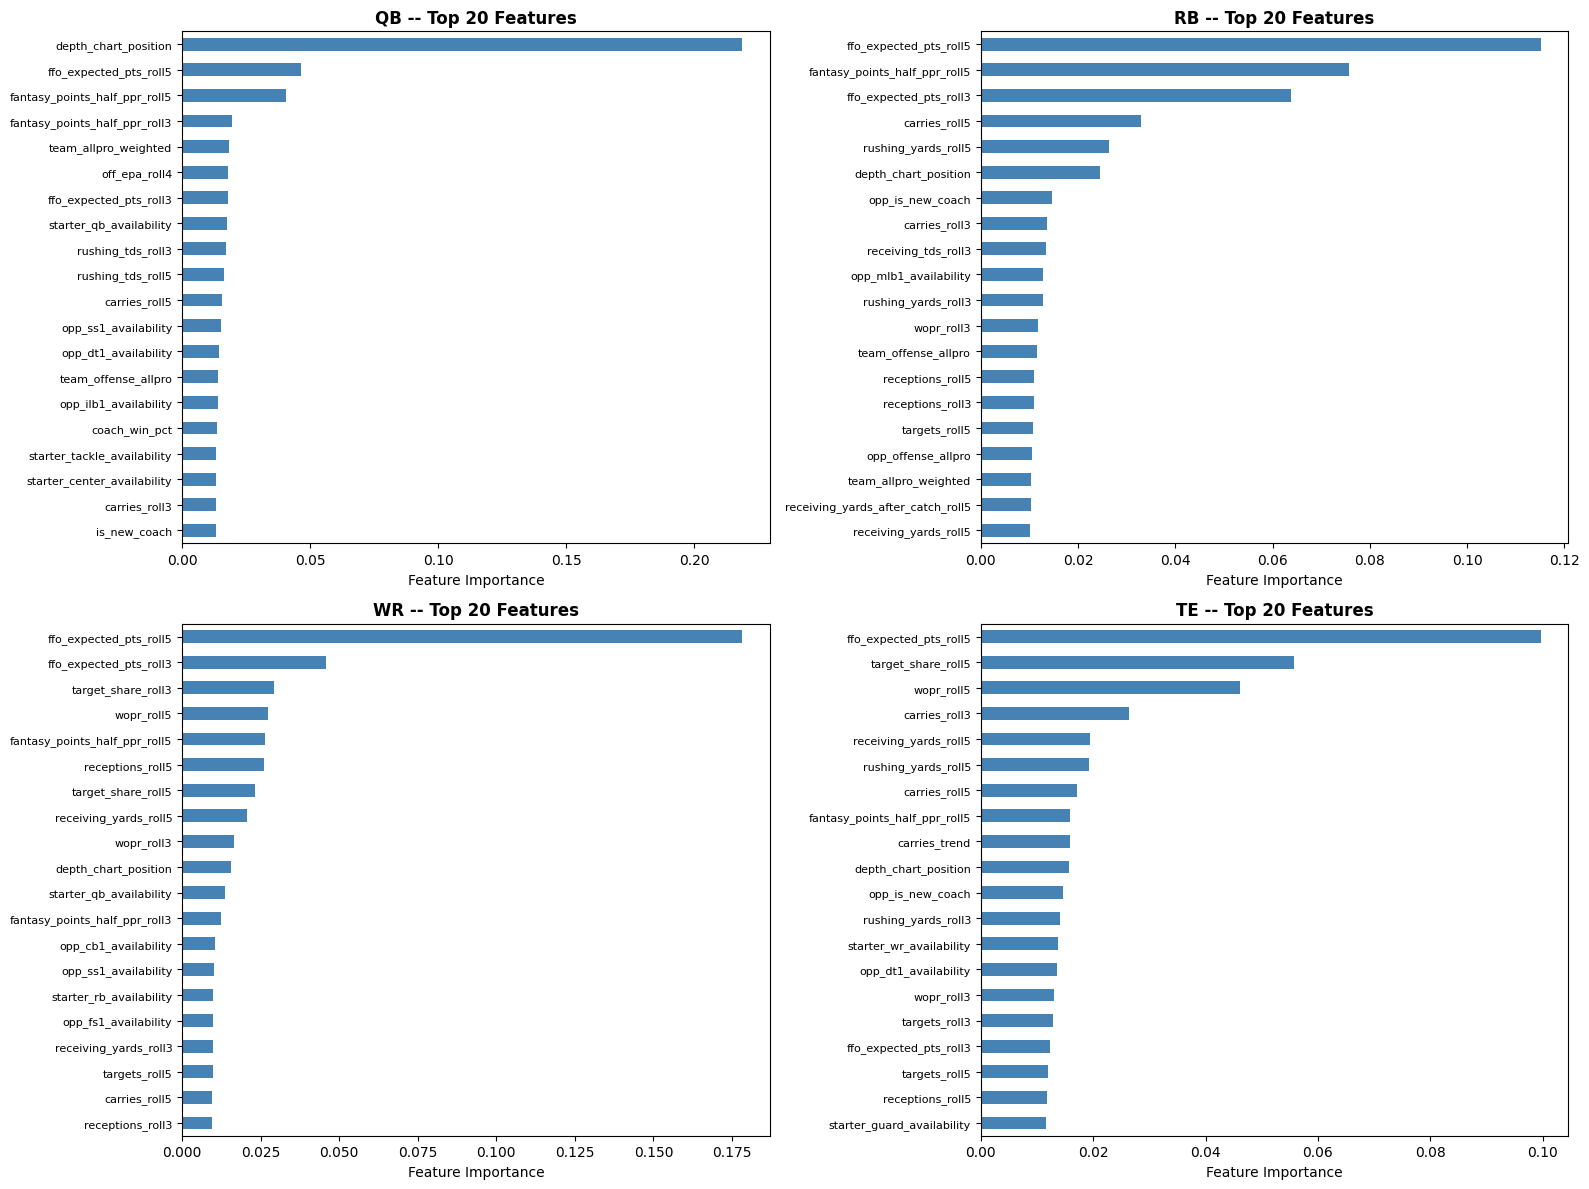

Saved feature_importance.png


In [55]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, pos in zip(axes, POSITIONS):
    saved = joblib.load(os.path.join(MODEL_DIR, f'{pos.lower()}_model.pkl'))
    feats = saved['feature_cols']
    top20 = pd.Series(saved['model'].feature_importances_, index=feats).sort_values().tail(20)

    top20.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{pos} -- Top 20 Features', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature Importance')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved feature_importance.png')


## How to Read the Evaluation Metrics

**MAE (Mean Absolute Error)** is the average of how far off each prediction was, ignoring direction.
If predictions were off by 3, 7, 2, 5, and 8 points across 5 weeks, MAE = (3+7+2+5+8)/5 = **5.0 pts**.

| Position | Model MAE | What it means in fantasy terms |
|----------|-----------|-------------------------------|
| QB | ~7 pts | Roughly the difference between a 2-TD and 3-TD game |
| RB | ~4.5 pts | About one extra scoring carry |
| WR | ~4 pts | About 1 reception and 30 yards |
| TE | ~3.3 pts | Tightest position — TE usage is most predictable week-to-week |

**RMSE (Root Mean Squared Error)** is similar but punishes large misses harder.
A big gap between RMSE and MAE (e.g. QB: 8.77 vs 7.11) means the model has occasional blowup weeks
where it misses badly — outlier performances like a QB going off for 40+ points or cratering to 5.

**Baseline MAE** is what you get by simply predicting each player's own 3-week rolling average — no model,
no features, just recent history. The model beating baseline on every position confirms the added features
(Vegas lines, defensive metrics, injuries, all-pro quality, coach win %) are contributing real signal.

**Within 5 pts / Within 10 pts** — the most intuitive metrics for fantasy:
within 5 pts means the model was within a comfortable margin; within 10 pts covers most usable predictions.

**Error column in player tables** is signed: positive = model over-predicted, negative = under-predicted.
Per-player MAE vs baseline MAE at the bottom of each table shows whether the model added value
over a naive guess for that specific player.

In [56]:
from scipy.stats import pearsonr

print('=== 2025 Holdout Results ===')
print()

all_preds = {}

for pos in POSITIONS:
    pos_df  = df[df['position'] == pos]
    test    = pos_df[pos_df['season'] == TEST_SEASON].copy()
    y_true  = test[TARGET_COL]
    saved   = joblib.load(os.path.join(MODEL_DIR, f'{pos.lower()}_model.pkl'))
    y_pred  = saved['model'].predict(test[saved['feature_cols']])
    test['predicted'] = y_pred
    all_preds[pos]    = test

    mae          = mean_absolute_error(y_true, y_pred)
    rmse         = root_mean_squared_error(y_true, y_pred)
    baseline_mae = mean_absolute_error(y_true, test['fantasy_points_half_ppr_roll3'])
    corr, _      = pearsonr(y_true, y_pred)
    within5      = (abs(y_true - y_pred) <= 5).mean() * 100
    within10     = (abs(y_true - y_pred) <= 10).mean() * 100

    print(f'--- {pos} ---')
    print(f'  Average error (MAE):          {mae:.1f} pts   (baseline: {baseline_mae:.1f} pts)')
    print(f'  Typical error range (RMSE):   {rmse:.1f} pts')
    print(f'  Correlation (pred vs actual): {corr:.3f}')
    print(f'  Within 5 pts:  {within5:.1f}%  |  Within 10 pts: {within10:.1f}%')
    print()


=== 2025 Holdout Results ===

--- QB ---
  Average error (MAE):          7.1 pts   (baseline: 7.5 pts)
  Typical error range (RMSE):   8.7 pts
  Correlation (pred vs actual): 0.345
  Within 5 pts:  41.0%  |  Within 10 pts: 75.1%

--- RB ---
  Average error (MAE):          4.5 pts   (baseline: 4.6 pts)
  Typical error range (RMSE):   6.6 pts
  Correlation (pred vs actual): 0.571
  Within 5 pts:  70.3%  |  Within 10 pts: 90.2%

--- WR ---
  Average error (MAE):          3.9 pts   (baseline: 4.1 pts)
  Typical error range (RMSE):   5.4 pts
  Correlation (pred vs actual): 0.539
  Within 5 pts:  73.0%  |  Within 10 pts: 92.9%

--- TE ---
  Average error (MAE):          3.3 pts   (baseline: 3.5 pts)
  Typical error range (RMSE):   4.7 pts
  Correlation (pred vs actual): 0.466
  Within 5 pts:  78.9%  |  Within 10 pts: 95.2%



In [57]:
# Patrick Mahomes (QB) -- 2025 full season
_test   = all_preds['QB'].copy()
_player = _test[_test['player_display_name'] == 'Patrick Mahomes'].copy()
_player['error']    = (_player['predicted'] - _player[TARGET_COL]).round(1)
_player['baseline'] = _player['fantasy_points_half_ppr_roll3'].round(1)

out = (
    _player[['week', 'opponent_team', 'baseline', 'predicted', TARGET_COL, 'error']]
    .rename(columns={TARGET_COL: 'actual', 'predicted': 'model_pred', 'opponent_team': 'opp'})
    .assign(model_pred=lambda d: d['model_pred'].round(1))
    .sort_values('week')
    .reset_index(drop=True)
)
print(out.to_string(index=True))
print()
print(f'Weeks: {len(_player)}  |  '
      f'Model MAE: {abs(_player["error"]).mean():.2f}  |  '
      f'Baseline MAE: {abs(_player["baseline"] - _player[TARGET_COL]).mean():.2f}')


    week  opp  baseline  model_pred  actual  error
0      1  LAC      21.8   19.400000   22.08   -2.7
1      2  PHI      25.2   28.500000   13.16   15.3
2      3  NYG      24.7   18.000000   27.30   -9.3
3      4  BAL      20.4   17.799999   26.72   -9.0
4      5  JAX      20.8   19.400000   31.48  -12.1
5      6  DET      22.4   28.400000   26.24    2.2
6      7   LV      28.5   21.600000   22.96   -1.4
7      8  WAS      28.1   19.700001   10.50    9.2
8      9  BUF      26.9   20.700001   13.34    7.4
9     11  DEN      19.9   22.500000   17.08    5.4
10    12  IND      15.6   20.100000   29.44   -9.3
11    13  DAL      13.6   17.299999    5.80   11.5
12    14  HOU      20.0   17.799999   13.06    4.7

Weeks: 13  |  Model MAE: 7.65  |  Baseline MAE: 7.99


In [58]:
# Justin Jefferson (WR) -- 2025 full season
_test   = all_preds['WR'].copy()
_player = _test[_test['player_display_name'] == 'Justin Jefferson'].copy()
_player['error']    = (_player['predicted'] - _player[TARGET_COL]).round(1)
_player['baseline'] = _player['fantasy_points_half_ppr_roll3'].round(1)

out = (
    _player[['week', 'opponent_team', 'baseline', 'predicted', TARGET_COL, 'error']]
    .rename(columns={TARGET_COL: 'actual', 'predicted': 'model_pred', 'opponent_team': 'opp'})
    .assign(model_pred=lambda d: d['model_pred'].round(1))
    .sort_values('week')
    .reset_index(drop=True)
)
print(out.to_string(index=True))
print()
print(f'Weeks: {len(_player)}  |  '
      f'Model MAE: {abs(_player["error"]).mean():.2f}  |  '
      f'Baseline MAE: {abs(_player["baseline"] - _player[TARGET_COL]).mean():.2f}')


    week  opp  baseline  model_pred  actual  error
0      1  CHI      17.2        14.5     9.6    4.9
1      2  ATL      11.0        15.4    10.0    5.4
2      3  CIN       9.8        13.7    17.6   -3.9
3      4  PIT      10.8        12.0    15.8   -3.8
4      5  CLE      12.4         9.7    10.4   -0.7
5      7  PHI      14.5        11.7    10.9    0.8
6      8  LAC      14.6        12.8    13.7   -0.9
7      9  DET      12.4         9.1     5.7    3.4
8     10  BAL      11.7        12.8     8.6    4.2
9     11  CHI      10.1         9.2     6.8    2.4
10    12   GB       9.3         8.0     1.4    6.6
11    13  SEA       7.0         8.4     2.1    6.3
12    14  WAS       5.6        10.3     3.2    7.1
13    15  DAL       3.4         8.8    11.5   -2.7
14    16  NYG       2.2         5.5     5.0    0.5
15    17  DET       5.6         9.9    14.4   -4.5

Weeks: 16  |  Model MAE: 3.63  |  Baseline MAE: 4.74


In [59]:
# Saquon Barkley (RB) -- 2025 full season
_test   = all_preds['RB'].copy()
_player = _test[_test['player_display_name'] == 'Saquon Barkley'].copy()
_player['error']    = (_player['predicted'] - _player[TARGET_COL]).round(1)
_player['baseline'] = _player['fantasy_points_half_ppr_roll3'].round(1)

out = (
    _player[['week', 'opponent_team', 'baseline', 'predicted', TARGET_COL, 'error']]
    .rename(columns={TARGET_COL: 'actual', 'predicted': 'model_pred', 'opponent_team': 'opp'})
    .assign(model_pred=lambda d: d['model_pred'].round(1))
    .sort_values('week')
    .reset_index(drop=True)
)
print(out.to_string(index=True))
print()
print(f'Weeks: {len(_player)}  |  '
      f'Model MAE: {abs(_player["error"]).mean():.2f}  |  '
      f'Baseline MAE: {abs(_player["baseline"] - _player[TARGET_COL]).mean():.2f}')


    week  opp  baseline  model_pred  actual  error
0      1  DAL      17.8   15.300000    16.4   -1.1
1      2   KC      20.4   16.200001     7.5    8.7
2      3   LA      16.9   16.200001    15.4    0.8
3      4   TB      13.4   12.700000    16.3   -3.6
4      5  DEN      13.1    7.800000     7.7    0.1
5      6  NYG      13.1   11.900000     4.7    7.2
6      7  MIN      13.1    9.300000    31.4  -22.1
7      8  NYG       9.6    8.400000    11.6   -3.2
8     10   GB      14.6   12.100000     9.5    2.6
9     11  DET      15.9   12.800000     8.9    3.9
10    12  DAL      17.5   11.600000     5.6    6.0
11    13  CHI      10.0   12.300000    18.2   -5.9
12    14  LAC       8.0    9.400000    16.2   -6.8
13    15   LV      10.9    7.700000    21.2  -13.5
14    16  WAS      13.3    8.600000     6.8    1.8

Weeks: 15  |  Model MAE: 5.82  |  Baseline MAE: 7.33
